In [1]:
import pandas as pd

PATH = "00_data/"

payments = pd.read_csv(f"{PATH}olist_order_payments_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}olist_orders_dataset.csv", encoding="utf-8-sig")
products = pd.read_csv(f"{PATH}olist_products_dataset.csv", encoding="utf-8-sig")
customers = pd.read_csv(f"{PATH}olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}olist_order_items_dataset.csv", encoding="utf-8-sig")
reviews = pd.read_csv(f"{PATH}olist_order_reviews_dataset.csv", encoding="utf-8-sig")
sellers = pd.read_csv(f"{PATH}olist_sellers_dataset.csv", encoding="utf-8-sig")
category_name = pd.read_csv(f"{PATH}product_category_name_translation.csv", encoding="utf-8-sig")

In [5]:
orders.info()
# orders = orders.dropna()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [6]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [7]:
import pandas as pd

merged_order = pd.merge(orders, payments, on="order_id")
merged_order_payment_date = merged_order[["order_purchase_timestamp", "payment_value"]].copy()

In [10]:
merged_order_payment_date["order_purchase_timestamp"] = pd.to_datetime(merged_order_payment_date["order_purchase_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")

In [12]:
merged_order_payment_date

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,18.12
1,2017-10-02 10:56:33,2.00
2,2017-10-02 10:56:33,18.59
3,2018-07-24 20:41:37,141.46
4,2018-08-08 08:38:49,179.12
...,...,...
100734,2017-03-09 09:54:05,85.08
100735,2018-02-06 12:58:58,195.00
100736,2017-08-27 14:46:43,271.01
100737,2018-01-08 21:28:27,441.16


In [13]:
merged_order_payment_date["year"] = merged_order_payment_date["order_purchase_timestamp"].dt.year 
merged_order_payment_date["month"] = merged_order_payment_date["order_purchase_timestamp"].dt.month
merged_order_payment_date["quarter"] = merged_order_payment_date["order_purchase_timestamp"].dt.quarter 
merged_order_payment_date["monthday"] = merged_order_payment_date["order_purchase_timestamp"].dt.day 
merged_order_payment_date["weekday"] = merged_order_payment_date["order_purchase_timestamp"].dt.weekday 
merged_order_payment_date["hour"] = merged_order_payment_date["order_purchase_timestamp"].dt.hour 
merged_order_payment_date["minute"] = merged_order_payment_date["order_purchase_timestamp"].dt.minute 

In [14]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value,year,month,quarter,monthday,weekday,hour,minute
0,2017-10-02 10:56:33,18.12,2017,10,4,2,0,10,56
1,2017-10-02 10:56:33,2.00,2017,10,4,2,0,10,56
2,2017-10-02 10:56:33,18.59,2017,10,4,2,0,10,56
3,2018-07-24 20:41:37,141.46,2018,7,3,24,1,20,41
4,2018-08-08 08:38:49,179.12,2018,8,3,8,2,8,38


In [ ]:
# 연도별, 요일별 매출 추이를 확인 -> 의사결정에 영향을 주는 요소들이었기 때문에 추출 & 시각화 -> 설득, 공감, 결론 도출

In [ ]:
# 계절별 트랜드 분석 (4계절 -> 분기 quarter)

In [16]:
merged_order_payment_quarter = merged_order_payment_date[["quarter", "payment_value"]].copy()

In [18]:
merged_order_payment_quarter = merged_order_payment_quarter.groupby("quarter").sum()

In [19]:
merged_order_payment_quarter

,payment_value
quarter,
1,3977098.94
2,4721382.50
3,3926177.93
4,2795023.48


In [20]:
merged_order_payment_quarter = merged_order_payment_quarter.reset_index()

In [22]:
merged_order_payment_quarter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   quarter        4 non-null      int32  
 1   payment_value  4 non-null      float64
dtypes: float64(1), int32(1)
memory usage: 180.0 bytes


In [23]:
merged_order_payment_quarter["quarter"] = merged_order_payment_quarter["quarter"].astype(object)

In [24]:
merged_order_payment_quarter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   quarter        4 non-null      object 
 1   payment_value  4 non-null      float64
dtypes: float64(1), object(1)
memory usage: 196.0+ bytes


In [25]:
def func(row) :
    if row["quarter"] == 1 :
        row["quarter"] = "1Q"
    elif row["quarter"] == 2 :
        row["quarter"] = "2Q"
    elif row["quarter"] == 3 :
        row["quarter"] = "3Q"
    elif row["quarter"] == 4 :
        row["quarter"] = "4Q"
    return row

In [26]:
merged_order_payment_quarter = merged_order_payment_quarter.apply(func, axis=1) # axis=1 행 단위로 움직임

In [27]:
merged_order_payment_quarter

,quarter,payment_value
0,1Q,3977098.94
1,2Q,4721382.50
2,3Q,3926177.93
3,4Q,2795023.48


In [28]:
merged_order_payment_quarter = merged_order_payment_quarter.set_index("quarter")

In [29]:
merged_order_payment_quarter

,payment_value
quarter,
1Q,3977098.94
2Q,4721382.50
3Q,3926177.93
4Q,2795023.48


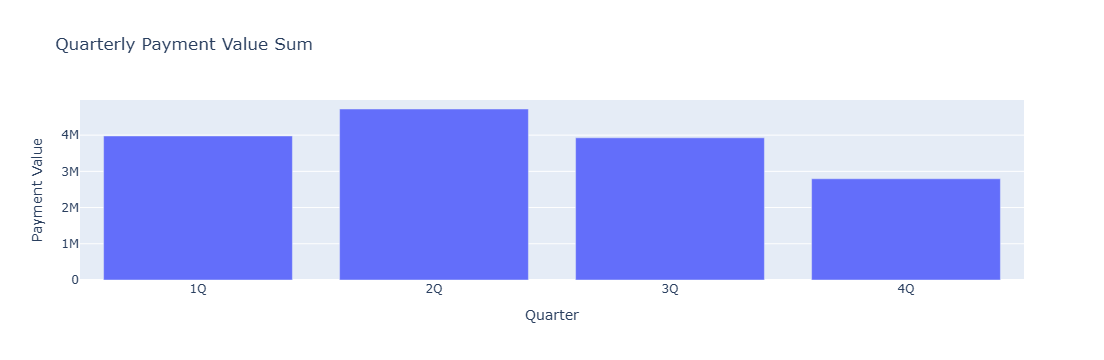

In [31]:
import plotly.express as px

fig = px.bar(
    x=merged_order_payment_quarter.index,
    y=merged_order_payment_quarter["payment_value"],
    title= "Quarterly Payment Value Sum",
    labels={
        "x": "Quarter",
        "y": "Payment Value"
    }
)


fig.show()

In [32]:
colors = ["#03588c"] * len(merged_order_payment_quarter.index)
colors[1] = "#f24472"

In [33]:
colors

['#03588c', '#f24472', '#03588c', '#03588c']

In [ ]:
# 시간대별 트랜드 분석

In [35]:
merged_order_payment_hour = merged_order_payment_date[["hour", "payment_value"]].copy()
merged_order_payment_hour = merged_order_payment_hour.groupby("hour").sum()
merged_order_payment_hour

,payment_value
hour,
0,360158.45
1,171441.04
2,64572.21
3,37551.29
4,28209.97
5,25620.74
6,63215.01
7,173948.18
8,452343.96


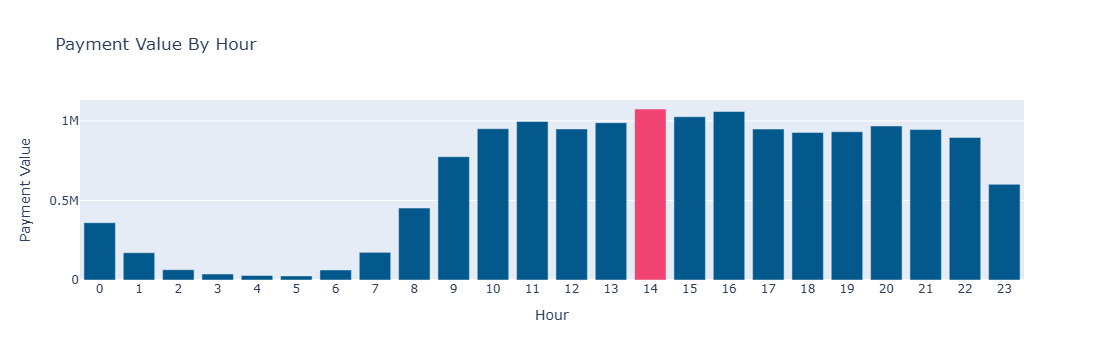

In [40]:
import plotly.express as px

fig = px.bar(
    x=merged_order_payment_hour.index,
    y=merged_order_payment_hour["payment_value"],
    title= "Payment Value By Hour",
    labels={
        "x": "Hour",
        "y": "Payment Value"
    }
)

fig.update_layout(
    xaxis = {
       "dtick": 1
    }
)

fig.update_traces(
    marker_color = colors
)
fig.show()

In [38]:
colors = ["#03588c"] * len(merged_order_payment_hour.index)
colors[14] = "#f24472"

In [39]:
colors

['#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#f24472',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c']

In [ ]:
# 분 별 매출 분석

In [41]:
merged_order_payment_minute = merged_order_payment_date[["minute", "payment_value"]].copy()

In [42]:
merged_order_payment_minute

,minute,payment_value
0,56,18.12
1,56,2.00
2,56,18.59
3,41,141.46
4,38,179.12
...,...,...
100734,54,85.08
100735,58,195.00
100736,46,271.01
100737,28,441.16


In [44]:
merged_order_payment_minute = merged_order_payment_minute.groupby("minute").sum()
merged_order_payment_minute.head()

,payment_value
minute,
0,253410.99
1,247286.12
2,220971.41
3,245626.28
4,265087.98


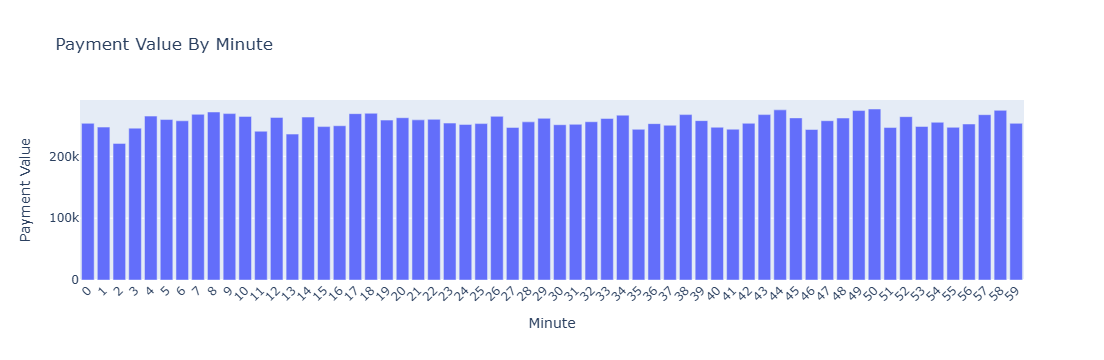

In [46]:
import plotly.express as px

fig = px.bar(
    x = merged_order_payment_minute.index,
    y = merged_order_payment_minute["payment_value"],
    title = "Payment Value By Minute",
    labels={
        "x": "Minute",
        "y": "Payment Value"
    }
)

fig.update_xaxes(
    dtick = 1
)
fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

# 요일 : 월요일 / 시간 : 9분 간격
# 요일에 따라서 시간의 트랜드가 영향을 받을까? - 상관관계

In [58]:
merged_order_payment_hour_weekday = merged_order_payment_date[["weekday", "hour", "payment_value"]].copy()

In [59]:
merged_order_payment_hour_weekday

,weekday,hour,payment_value
0,0,10,18.12
1,0,10,2.00
2,0,10,18.59
3,1,20,141.46
4,2,8,179.12
...,...,...,...
100734,3,9,85.08
100735,1,12,195.00
100736,6,14,271.01
100737,0,21,441.16


In [63]:
merged_order_payment_hour_weekday = merged_order_payment_hour_weekday.groupby(["weekday", "hour"]).sum()

In [64]:
merged_order_payment_hour_weekday

payment_value
weekday hour               
0       0          46807.42
        1          17734.77
        2           7462.56
        3           6442.62
        4           2138.02
...                     ...
6       19        140127.39
        20        150543.96
        21        135431.31
        22        127866.74
        23         82991.95

[168 rows x 1 columns]

In [69]:
merged_order_payment_hour_weekday = merged_order_payment_hour_weekday.reset_index()

In [ ]:
# 멀티인덱스 : 여러개의 인덱스 생성

In [67]:
# 두번째 행의 첫번째 값 (멀티인덱스라고 가정했을 때) -> (0, 1)
merged_order_payment_hour_weekday.index[0][1]

np.int32(0)

In [70]:
merged_order_payment_hour_weekday

,weekday,hour,payment_value
0,0,0,46807.42
1,0,1,17734.77
2,0,2,7462.56
3,0,3,6442.62
4,0,4,2138.02
...,...,...,...
163,6,19,140127.39
164,6,20,150543.96
165,6,21,135431.31
166,6,22,127866.74


In [94]:
def func(row) :
    if row["weekday"] == 0 : 
        row["weekday"] = "Mon"
    elif row["weekday"] == 1 : 
        row["weekday"] = "Tue"
    elif row["weekday"] == 2 : 
        row["weekday"] = "Wed"
    elif row["weekday"] == 3 : 
        row["weekday"] = "Thu"
    elif row["weekday"] == 4 : 
        row["weekday"] = "Fri"
    elif row["weekday"] == 5 : 
        row["weekday"] = "Sat"
    elif row["weekday"] == 6 : 
        row["weekday"] = "Sun"

    return row

In [95]:
merged_order_payment_hour_weekday["weekday"] = merged_order_payment_hour_weekday["weekday"].astype(object)

In [96]:
merged_order_payment_hour_weekday = merged_order_payment_hour_weekday.apply(func, axis=1)

In [97]:
merged_order_payment_hour_weekday

,weekday,hour,payment_value
0,NaN,0,46807.42
1,NaN,1,17734.77
2,NaN,2,7462.56
3,NaN,3,6442.62
4,NaN,4,2138.02
...,...,...,...
163,Sun,19,140127.39
164,Sun,20,150543.96
165,Sun,21,135431.31
166,Sun,22,127866.74


In [ ]:
# 특정 행의 이름을 커스텀 방식으로 정렬 순서를 정의하고자 할때
# Categorical() 사용 -> 매개변수로 어떤 열을 기준으로 어떤 순서에 따라서 정렬을 매길것인가를 정의

In [98]:
import pandas as pd

merged_order_payment_hour_weekday["weekday"] = pd.Categorical(merged_order_payment_hour_weekday["weekday"], categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], ordered=True)

In [99]:
merged_order_payment_hour_weekday.sort_values(by=["weekday", "hour"], ascending=True)

,weekday,hour,payment_value
144,Sun,0,38888.45
145,Sun,1,20137.20
146,Sun,2,11965.82
147,Sun,3,6326.13
148,Sun,4,3914.48
...,...,...,...
70,NaN,22,128446.03
142,NaN,22,79660.03
23,NaN,23,115206.30
71,NaN,23,82444.91


In [ ]:
# 서로 다른 2개의 열의 상관관계를 확인(분석) 하기 위해 heatmap 차트 사용

In [101]:
import pandas as pd
doc = pd.read_csv("COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/04-01-2020.csv", encoding="utf-8-sig")

In [102]:
doc

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
0,45001.0,Abbeville,South Carolina,US,2020-04-01 21:58:49,34.223334,-82.461707,4,0,0,4,"Abbeville, South Carolina, US"
1,22001.0,Acadia,Louisiana,US,2020-04-01 21:58:49,30.295065,-92.414197,47,1,0,46,"Acadia, Louisiana, US"
2,51001.0,Accomack,Virginia,US,2020-04-01 21:58:49,37.767072,-75.632346,7,0,0,7,"Accomack, Virginia, US"
3,16001.0,Ada,Idaho,US,2020-04-01 21:58:49,43.452658,-116.241552,195,3,0,192,"Ada, Idaho, US"
4,19001.0,Adair,Iowa,US,2020-04-01 21:58:49,41.330756,-94.471059,1,0,0,1,"Adair, Iowa, US"
...,...,...,...,...,...,...,...,...,...,...,...,...
2517,82604.0,NaN,Wales,United Kingdom,2020-04-01 21:58:49,52.130700,-3.783700,0,198,0,0,"Wales, United Kingdom"
2518,NaN,NaN,NaN,Nauru,2020-04-01 21:58:49,-0.522800,166.931500,0,0,0,0,Nauru
2519,NaN,NaN,Niue,New Zealand,2020-04-01 21:58:49,-19.054400,-169.867200,0,0,0,0,"Niue, New Zealand"
2520,NaN,NaN,NaN,Tuvalu,2020-04-01 21:58:49,-7.109500,177.649300,0,0,0,0,Tuvalu


In [104]:
doc2 = doc.corr(numeric_only=True)

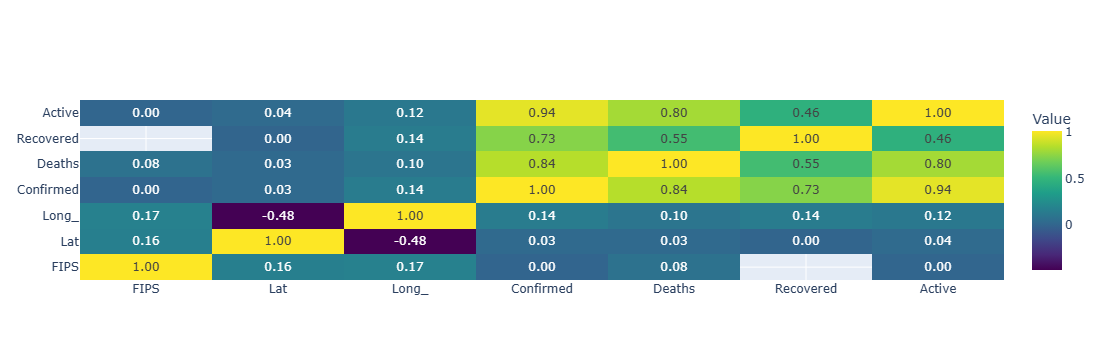

In [115]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Heatmap(
        z = doc2.values,
        x = doc2.columns,
        y = doc2.index,
        colorscale="Viridis",
        colorbar={
            "title": "Value"
        },
        text = doc2.values,
        texttemplate="%{z:.2f}",
        hovertemplate="x: %{x}<b>y: %{y}"
    )
)

fig.show()

In [ ]:
# 피봇테이블

In [114]:
pivot_df = merged_order_payment_hour_weekday.pivot(index="weekday", columns="hour", values="payment_value")

ValueError: Index contains duplicate entries, cannot reshape

In [116]:
import plotly.graph_objects as go

fig = go.Figure(
    DATA = go.Heatmap(
        z = pivot_df.values,
        x = pivot_df.columns,
        y = pivot_df.index,
        text = pivot_df.values,
        texttemplate="%{z:,.0f}"
    )
)

fig.update_layout(
    title = {
        "text": "Heatmap",
        "x": 0.5,
        "y": 0.9
    },
    xaxis = {
        "dtick": 1,
        "tickformat": "d"
    }
)

fig.show()

SyntaxError: unterminated string literal (detected at line 20) (1063336234.py, line 20)